In [2]:
#first I uploaded the file train_snli.text on my google drive for email ID: Akshatshrinate.bt21ece@pec.edu.in
#now from my google drive I will import the file which needs that I mount my drive over the colab file
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Now I copied the file path in a variable and using that I am opening the file
#Once the file is opened in read mode, I want that the lines are stored in a list with variable name data

file_path = '/content/drive/My Drive/train_snli.txt'
with open(file_path, 'r') as file:
    training_data = file.readlines()
    print(training_data[:5])

#now the issue is that the data is not in tabular form
#there is text and numeric based data with two '\t' and the third with '\n' signifying there are 3 columns for each row.

['A person on a horse jumps over a broken down airplane.\tA person is at a diner, ordering an omelette.\t0\n', 'A person on a horse jumps over a broken down airplane.\tA person is outdoors, on a horse.\t1\n', 'Children smiling and waving at camera\tThere are children present\t1\n', 'Children smiling and waving at camera\tThe kids are frowning\t0\n', 'A boy is jumping on skateboard in the middle of a red bridge.\tThe boy skates down the sidewalk.\t0\n']


In [72]:
#Installing/importing some of the basic dependancies that will be used
import re
import csv
from tqdm import tqdm
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder



In [45]:
#to convert the dataset into tabular form, a csv file is created called training data
#the data set contains three columns per row, one is source text, the other is copied text, and the third is a label or classification
#The classification is either 1 or 0 depending on it is copied or not

with open('training_data.csv', 'w', newline='') as csvfile:
    filenames = ['source_text', 'plag_text', 'classification']
    writer = csv.DictWriter(csvfile, fieldnames=filenames)
    writer.writeheader()

    for line in tqdm(training_data):
        parts = line.strip().split('\t')
        source_text = parts[0]
        plag_text = parts[1]
        classification = int(parts[2])

        writer.writerow({
            'source_text': source_text,
            'plag_text': plag_text,
            'classification': classification
        })

print('CSV file created successfully...')

  0%|          | 0/367373 [00:00<?, ?it/s]

CSV file created successfully...


**THe Dataset has been Created. The next steps involve checking the dataset for null and Duplicate values and getting rid of these redundancies.**





In [46]:
dataset = pd.read_csv("training_data.csv")
dataset.head()

,source_text,plag_text,classification
0,A person on a horse jumps over a broken down a...,"A person is at a diner, ordering an omelette.",0
1,A person on a horse jumps over a broken down a...,"A person is outdoors, on a horse.",1
2,Children smiling and waving at camera,There are children present,1
3,Children smiling and waving at camera,The kids are frowning,0
4,A boy is jumping on skateboard in the middle o...,The boy skates down the sidewalk.,0


In [47]:
dataset.shape

(367373, 3)

In [48]:
# check for null values
print("Null values:", dataset.isnull().sum())

Null values: source_text       0
plag_text         4
classification    0
dtype: int64


In [49]:
# remove null values
dataset.dropna(inplace=True)

In [50]:
print("Null values after removing:", dataset.isnull().sum())

Null values after removing: source_text       0
plag_text         0
classification    0
dtype: int64


In [51]:
# check for duplicates
print("Duplicates:", dataset.duplicated().sum())

Duplicates: 454


In [52]:
# remove all the duplicates
dataset.drop_duplicates(inplace=True)


In [53]:
print("Duplicates after removing:", dataset.duplicated().sum())

Duplicates after removing: 0


In [54]:
#I just checked the final shape of the dataset which gives me an idea of the number of rows
dataset.shape

(366915, 3)

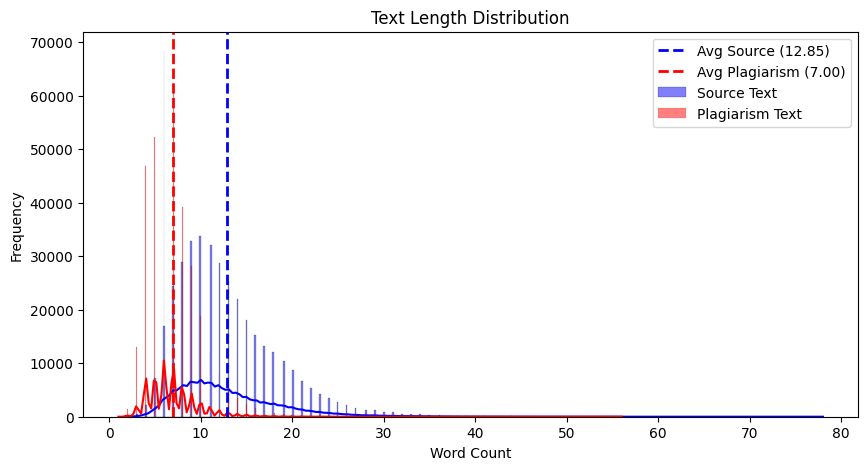

In [55]:
# To start understanding the two columns: the source_text and the plag_text
#I went through the process of creating a Text Length Distribution comparing word counts between source text and plagiarized text samples
#this is done to understand how the samples are different from each other and what model is suitable for building the plag checker

# Calculate source and plagiarism text lengths
dataset['source_text_length'] = dataset['source_text'].apply(lambda x: len(x.split()))
dataset['plag_text_length'] = dataset['plag_text'].apply(lambda x: len(x.split()))

#The histogram plotting
plt.figure(figsize=(10, 5))
sns.histplot(dataset['source_text_length'], color='blue', label='Source Text', kde=True)
sns.histplot(dataset['plag_text_length'], color='red', label='Plagiarism Text', kde=True)

# Calculate averages
avg_source_text_length = dataset['source_text_length'].mean()
avg_plag_text_length = dataset['plag_text_length'].mean()

# average lines for each were added in the graph
plt.axvline(avg_source_text_length, color='blue', linestyle='dashed', linewidth=2, label=f'Avg Source ({avg_source_text_length:.2f})')
plt.axvline(avg_plag_text_length, color='red', linestyle='dashed', linewidth=2, label=f'Avg Plagiarism ({avg_plag_text_length:.2f})')

# Presentation of the graph
plt.title('Text Length Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [59]:
#Cosine similarity is a measure of similarity between two non-zero vectors, by measuring the cosine of the angle between them.
#This value lies between between 0 and 1, where 1 indicates that the two texts are identical, and 0 indicates no similarity.
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
# Limit to first 2000 rows
num_rows_to_process = 15000
dataset_subset = dataset.head(num_rows_to_process)

# Initialize CountVectorizer
vectorizer = CountVectorizer()

# Variable to accumulate total cosine similarity
total_cos_sim = 0
num_rows = len(dataset_subset)

# Loop through each row in the dataset subset (first 2000 rows)
for index, row in dataset_subset.iterrows():
    source_text = row['source_text']
    plag_text = row['plag_text']

    # Vectorize the texts
    vectors = vectorizer.fit_transform([source_text, plag_text])

    # Calculate cosine similarity between the two vectors
    cos_sim = cosine_similarity(vectors[0], vectors[1])

    # Add cosine similarity to total
    total_cos_sim += cos_sim[0][0]

# Calculate average cosine similarity
avg_cos_sim = total_cos_sim / num_rows

# Print the average cosine similarity
print(f"Average Cosine Similarity for first 2000 rows: {avg_cos_sim:.4f}")

Average Cosine Similarity for first 2000 rows: 0.3287


A similarity of 0.3 means that the two texts share some level of similarity, but it is not very strong. The texts have some overlap, but there's still a significant difference between them

In [66]:
!pip install xgboost
import xgboost as xgb
print(xgb.__version__)


2.1.4


In [67]:


# Combine source and plag text to create a single input for vectorization
texts = dataset['source_text'] + " " + dataset['plag_text']
labels = dataset['classification']

# TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(texts)

print(f" Shape of the data after TF-IDF: {X.shape}")

 Shape of the data after TF-IDF: (366915, 5000)


In [68]:
from sklearn.model_selection import train_test_split

# Split into 70% train and 30% temp (for validation and test)
X_train, X_temp, y_train, y_temp = train_test_split(X, labels, test_size=0.30, random_state=42)

# Further split the 30% temp set into 50% validation and 50% test (which will be 15% each of the original data)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 256840
Validation set size: 55037
Test set size: 55038


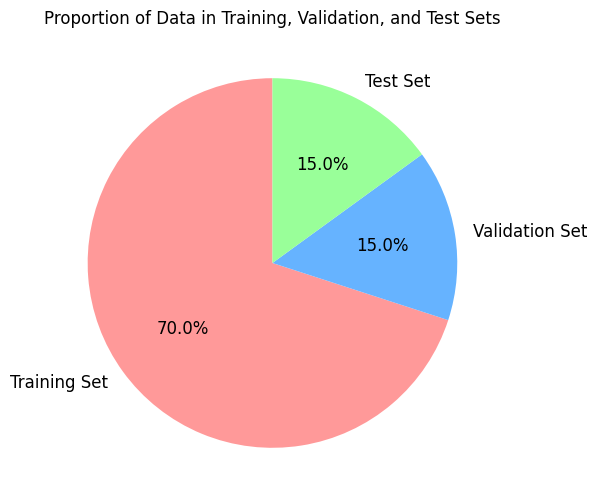

In [73]:
train_size = X_train.shape[0]
val_size = X_val.shape[0]
test_size = X_test.shape[0]

# Create a pie chart for the data split
sizes = [train_size, val_size, test_size]
labels = ['Training Set', 'Validation Set', 'Test Set']
colors = ['#ff9999','#66b3ff','#99ff99']

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, textprops={'fontsize': 12})
plt.title("Proportion of Data in Training, Validation, and Test Sets")
plt.show()

In [74]:
print(f"Training Data Shape: {X_train.shape}")
print(f"Validation Data Shape: {X_val.shape}")
print(f"Test Data Shape: {X_test.shape}")

Training Data Shape: (256840, 5000)
Validation Data Shape: (55037, 5000)
Test Data Shape: (55038, 5000)


In [75]:
label_encoder = LabelEncoder()

# Convert your data to DMatrix format (XGBoost's internal data structure)
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

# Set up the model parameters
params = {
    'eval_metric': 'logloss',
    'tree_method': 'hist',  # Use 'hist' method optimized for GPU
    'device': 'cuda',       # Train on GPU
    'objective': 'binary:logistic',  # Binary classification
}

# Train the model
model = xgb.train(params, dtrain, evals=[(dval, 'validation')], num_boost_round=100)

print("Model Training Completed with GPU")

# Predict on the test set
y_pred = model.predict(dtest)

# Convert predictions to binary class labels (0 or 1)
y_pred_binary = (y_pred > 0.5).astype(int)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Accuracy on Test Set: {accuracy:.4f}")

[0]	validation-logloss:0.67135
[1]	validation-logloss:0.65893
[2]	validation-logloss:0.65031
[3]	validation-logloss:0.64122
[4]	validation-logloss:0.63478
[5]	validation-logloss:0.62880
[6]	validation-logloss:0.62258
[7]	validation-logloss:0.61901
[8]	validation-logloss:0.61447
[9]	validation-logloss:0.61103
[10]	validation-logloss:0.60729
[11]	validation-logloss:0.60422
[12]	validation-logloss:0.60098
[13]	validation-logloss:0.59750
[14]	validation-logloss:0.59526
[15]	validation-logloss:0.59181
[16]	validation-logloss:0.58922
[17]	validation-logloss:0.58662
[18]	validation-logloss:0.58428
[19]	validation-logloss:0.58238
[20]	validation-logloss:0.58002
[21]	validation-logloss:0.57831
[22]	validation-logloss:0.57666
[23]	validation-logloss:0.57507
[24]	validation-logloss:0.57340
[25]	validation-logloss:0.57130
[26]	validation-logloss:0.56992
[27]	validation-logloss:0.56879
[28]	validation-logloss:0.56745
[29]	validation-logloss:0.56637
[30]	validation-logloss:0.56496
[31]	validation-lo

In [77]:
from hyperopt import fmin, tpe, hp, Trials
from hyperopt import STATUS_OK


def objective(params):
    print(f"Evaluating: {params}")

    model_params = {
        'eval_metric': 'logloss',
        'tree_method': 'hist',
        'device': 'cuda',
        'objective': 'binary:logistic',
        'max_depth': int(params['max_depth']),
        'learning_rate': params['learning_rate'],
        'subsample': params['subsample'],
        'colsample_bytree': params['colsample_bytree'],
    }

    # Collect evaluation results during training
    evals_result = {}

    model = xgb.train(
        model_params,
        dtrain,
        evals=[(dval, 'validation')],
        num_boost_round=int(params['num_boost_round']),
        evals_result=evals_result,
        verbose_eval=False  # No training logs printed
    )

    y_pred = model.predict(dval)
    y_pred_binary = (y_pred > 0.5).astype(int)
    accuracy = accuracy_score(y_val, y_pred_binary)

    return {'loss': -accuracy, 'status': STATUS_OK}

# ====== Define Hyperparameter Search Space ======
space = {
    'max_depth': hp.quniform('max_depth', 2, 10, 1),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'subsample': hp.uniform('subsample', 0.5, 1),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),
    'num_boost_round': hp.quniform('num_boost_round', 50, 300, 50),
}

# ====== Hyperopt Trials ======
trials = Trials()

# ====== Run Hyperparameter Tuning ======
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=10,
    trials=trials
)

print(f"\nBest Hyperparameters: {best}")

# ====== Train Final Model with Best Hyperparameters ======
final_params = {
    'eval_metric': 'logloss',
    'tree_method': 'hist',
    'device': 'cuda',
    'objective': 'binary:logistic',
    'max_depth': int(best['max_depth']),
    'learning_rate': best['learning_rate'],
    'subsample': best['subsample'],
    'colsample_bytree': best['colsample_bytree'],
}

# ==== Save evaluation results ====
evals_result = {}

final_model = xgb.train(
    final_params,
    dtrain,
    evals=[(dtrain, 'train'), (dval, 'validation')],
    num_boost_round=int(best['num_boost_round']),
    evals_result=evals_result,
    verbose_eval=True  # Optional: print logs during final training
)

# ====== Predict on Test Set ======
y_pred_final = final_model.predict(dtest)
y_pred_binary_final = (y_pred_final > 0.5).astype(int)

# ====== Final Test Accuracy ======
final_accuracy = accuracy_score(y_test, y_pred_binary_final)
print(f"Final Model Accuracy on Test Set: {final_accuracy:.4f}")



Evaluating: {'colsample_bytree': 0.9352624497216955, 'learning_rate': 0.22384131756503595, 'max_depth': 3.0, 'num_boost_round': 300.0, 'subsample': 0.6947250078967209}
Evaluating: {'colsample_bytree': 0.7263175585438335, 'learning_rate': 0.25426010982863406, 'max_depth': 10.0, 'num_boost_round': 100.0, 'subsample': 0.9091880513791306}
Evaluating: {'colsample_bytree': 0.6885332068581163, 'learning_rate': 0.20990459397156533, 'max_depth': 6.0, 'num_boost_round': 200.0, 'subsample': 0.9973362909374849}
Evaluating: {'colsample_bytree': 0.6488381276448831, 'learning_rate': 0.07744289460252433, 'max_depth': 3.0, 'num_boost_round': 50.0, 'subsample': 0.6886961361612632}
Evaluating: {'colsample_bytree': 0.7477971329258414, 'learning_rate': 0.07665670411569024, 'max_depth': 6.0, 'num_boost_round': 200.0, 'subsample': 0.9724041345655609}
Evaluating: {'colsample_bytree': 0.6064221814056145, 'learning_rate': 0.1704074940063234, 'max_depth': 7.0, 'num_boost_round': 200.0, 'subsample': 0.71905871982

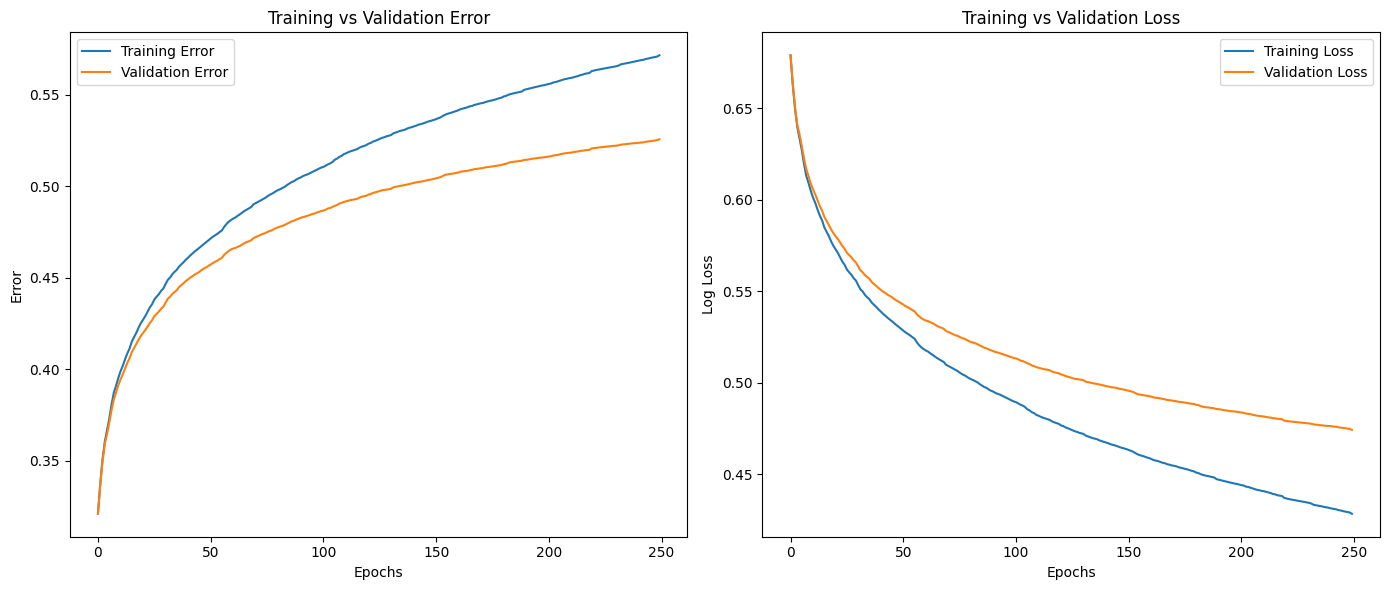

In [79]:
# Plot Accuracy and Loss
plt.figure(figsize=(14, 6))

# ===== Accuracy Plot =====
plt.subplot(1, 2, 1)
train_error = [1 - acc for acc in evals_result['train']['logloss']]
val_error = [1 - acc for acc in evals_result['validation']['logloss']]

plt.plot(train_error, label='Training Error')
plt.plot(val_error, label='Validation Error')
plt.title('Training vs Validation Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.legend()

# ===== Loss Plot =====
plt.subplot(1, 2, 2)
plt.plot(evals_result['train']['logloss'], label='Training Loss')
plt.plot(evals_result['validation']['logloss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.legend()

plt.tight_layout()
plt.show()

Final Model Accuracy on Test Set: 0.7804


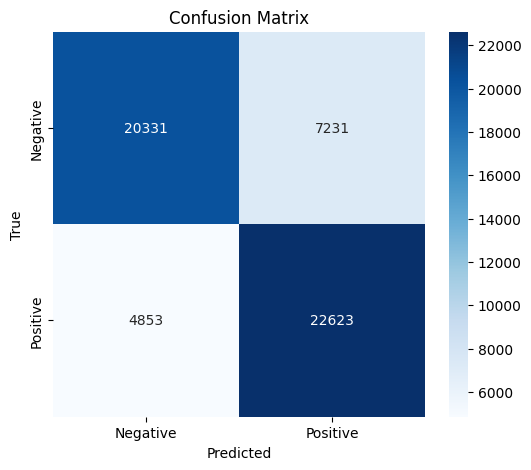


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.74      0.77     27562
           1       0.76      0.82      0.79     27476

    accuracy                           0.78     55038
   macro avg       0.78      0.78      0.78     55038
weighted avg       0.78      0.78      0.78     55038



In [80]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# ====== Predict on Test Set ======
y_pred_final = final_model.predict(dtest)
y_pred_binary_final = (y_pred_final > 0.5).astype(int)

# ====== Final Test Accuracy ======
final_accuracy = accuracy_score(y_test, y_pred_binary_final)
print(f"Final Model Accuracy on Test Set: {final_accuracy:.4f}")

# ====== Confusion Matrix ======
cm = confusion_matrix(y_test, y_pred_binary_final)  # Define the confusion matrix here

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Optionally: Calculate precision, recall, F1-score, etc.
print("\nClassification Report:")
print(classification_report(y_test, y_pred_binary_final))


In [81]:
final_model.save_model('plagiarism_detector_model.json')

In [82]:
loaded_model = xgb.Booster()
loaded_model.load_model('plagiarism_detector_model.json')

# Use the loaded model to predict
y_pred_loaded = loaded_model.predict(dtest)
y_pred_binary_loaded = (y_pred_loaded > 0.5).astype(int)

In [83]:
# Check accuracy
accuracy_loaded = accuracy_score(y_test, y_pred_binary_loaded)
print(f"Loaded Model Accuracy on Test Set: {accuracy_loaded:.4f}")

Loaded Model Accuracy on Test Set: 0.7804


In [84]:
import pickle
import random

# 1. Pick 4 random rows from your dataset
sample_indices = random.sample(range(len(dataset)), 5)
sample_data = dataset.iloc[sample_indices]

# 2. Prepare the combined text like during training
sample_texts = sample_data['source_text'] + " " + sample_data['plag_text']

# 3. Transform the text using the same vectorizer
X_sample = vectorizer.transform(sample_texts)

# 4. Convert into DMatrix for XGBoost
dtest_sample = xgb.DMatrix(X_sample)

# 5. Predict using your loaded model
sample_preds_prob = loaded_model.predict(dtest_sample)
sample_preds = (sample_preds_prob > 0.5).astype(int)

# 6. Print the results
for idx, (row_idx, prediction) in enumerate(zip(sample_indices, sample_preds)):
    print(f"\n Sample {idx+1}")
    print(f"Row Number in Dataset: {row_idx}")
    print(f"Source Text:\n{dataset.iloc[row_idx]['source_text']}")
    print(f"Plagiarized Text:\n{dataset.iloc[row_idx]['plag_text']}")
    print(f"Actual Label: {dataset.iloc[row_idx]['classification']}")
    print(f"Predicted Label: {prediction}")


 Sample 1
Row Number in Dataset: 254063
Source Text:
Asian man sweeping the walkway.
Plagiarized Text:
A person is cleaning
Actual Label: 1
Predicted Label: 1

 Sample 2
Row Number in Dataset: 353231
Source Text:
A man wearing jeans swings back his arm in preparation to release the bowling ball down the lane.
Plagiarized Text:
A naked man is reading a book.
Actual Label: 0
Predicted Label: 0

 Sample 3
Row Number in Dataset: 268142
Source Text:
A young couple dressed in matching red outfits performing a romantic dance.
Plagiarized Text:
A couple is in clothes.
Actual Label: 1
Predicted Label: 1

 Sample 4
Row Number in Dataset: 175126
Source Text:
A little girl wearing a white dress and a pink headband is holding a toy up to her ear as she watches people through the links in a fence.
Plagiarized Text:
A little girl in a white dress is napping on the couch.
Actual Label: 0
Predicted Label: 0

 Sample 5
Row Number in Dataset: 312784
Source Text:
A man scuba diving underwater.
Plagiarize

In [39]:
# What I found was a 80--100% accuracy on the dataset.